# MOM6 Input Files for anu-tub

This case is designed to run MOM6 with the tub sector domain, at 1° resolution.
These input files are a copy of `mom6-anu-tub-driver.ipynb` but re-written in Julia so I get more understanding of what is going on.

The input files are saved in netcdf format, and need to copied into the relevant input directories before the run.

In [1]:
one_degree_input = "/g/data/e14/jb2381/one-degree-anu-tub/input/anu-tub"
if pwd() != one_degree_input
    cd(one_degree_input)
end

using Pkg
Pkg.activate(".")
using NCDatasets, CairoMakie

  Activating project at `/g/data/e14/jb2381/one-degree-anu-tub/input/anu-tub`
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0] (cache misses: wrong dep version loaded (6))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Set up domain size and parameters

In [2]:
REa=6.37e6    # Radius of Earth
D = 4000      # Water depth
nx = 40       # number of gridpoints in x, y and z
ny = 200
nz = 75
rx = 1.0      # base resolution, in degrees

1.0

## Now, to make the horizontal grid - Mercator projection

Domain goes from:-70.275597151116 to 70.10931231215596, diff = -0.16628483896003843


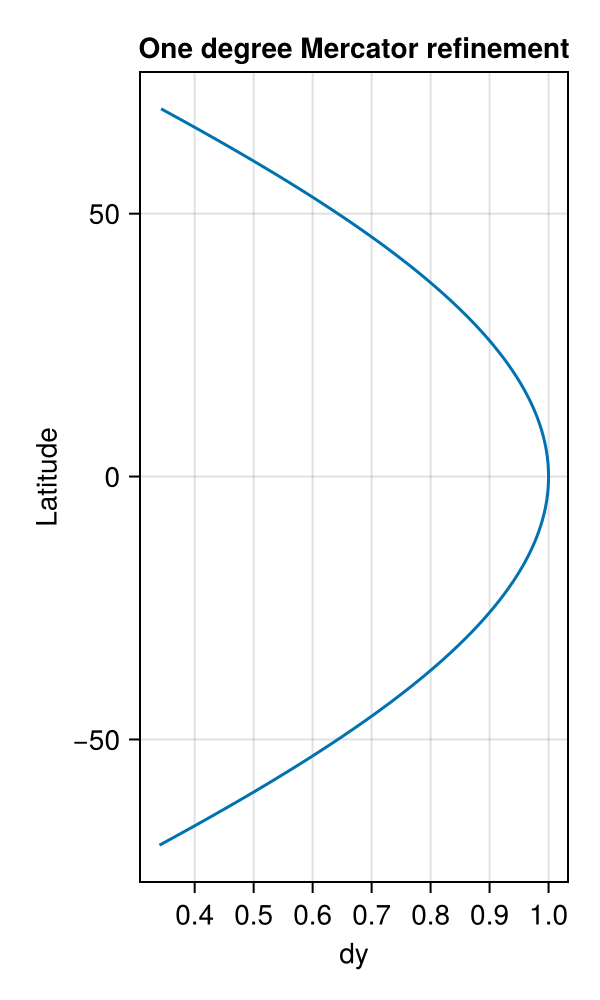

In [3]:
# latitude grid centre points
dy = zeros(ny)           # grid length
y = zeros(ny)            # grid points

Ystart = -70.275597151116         # degrees north
dYstart = rx*cos(deg2rad(Ystart)) # dy at southern boundary
y[1] = Ystart + 0.5*dYstart       # first h point
dy[1] = rx*cos(deg2rad(y[1]))     # dy at first h point

for i in 1:ny-1
    y[i+1] = y[i] + dy[i]
    dy[i+1] = rx*cos(deg2rad(y[i+1]))
end

Yend = y[end] + 0.5*dy[end]
diff = Yend + Ystart
println("Domain goes from:$Ystart to $Yend, diff = $diff")

# longitudinal grid centre points
dx = ones(nx)*rx
x = cumsum(dx)-dx/2

fig = Figure(size = (300, 500))
ax = Axis(fig[1, 1], xlabel = "dy", ylabel = "Latitude", title = "One degree Mercator refinement")
lines!(ax, dy, y)
fig

In [4]:
# Make a mesh of grids.
X = x .* ones(ny)'
Y = ones(nx) .* y'
nothing

## Now make land and bathymetry

In [5]:
## make land:
dc=59
h = @. - D*(2 ^(-0.4*X^2) * (1-0.5*2. ^(-0.003*abs(-Y-dc)^4)) - 0.9)/0.9
h = @. h - D*(2^(-0.4*(X-nx*rx)^2)*(1-0.5*2^(-0.003*abs(-Y-dc)^4)) - 0.9)/0.9 - D
h = ifelse.(h.<0,0,h)

# ## add in southern shelf
shelf_depth = 800
sws = 3   ## shelf width scale in degrees
htmp = D*ones(size(h))
htmp = ifelse.(Y .< Ystart+sws, shelf_depth .* (1 .+ (Y .- (Ystart.+sws)).^3/(sws.^3)), htmp)
htmp = ifelse.(Y .≥ Ystart+sws .&& Y .< Ystart+2*sws, 
               shelf_depth .+ (D.-shelf_depth)/2 .*(Y.-(Ystart.+sws)).^3/(sws.^3), 
               htmp)
htmp = ifelse.(Y .≥ Ystart+2*sws .&& Y .< Ystart+3*sws,
               D .+ (D .- shelf_depth)/2 .* (Y.-(Ystart+3*sws)).^3/(sws.^3),
               htmp)
h = ifelse.(h .< htmp, h, htmp);

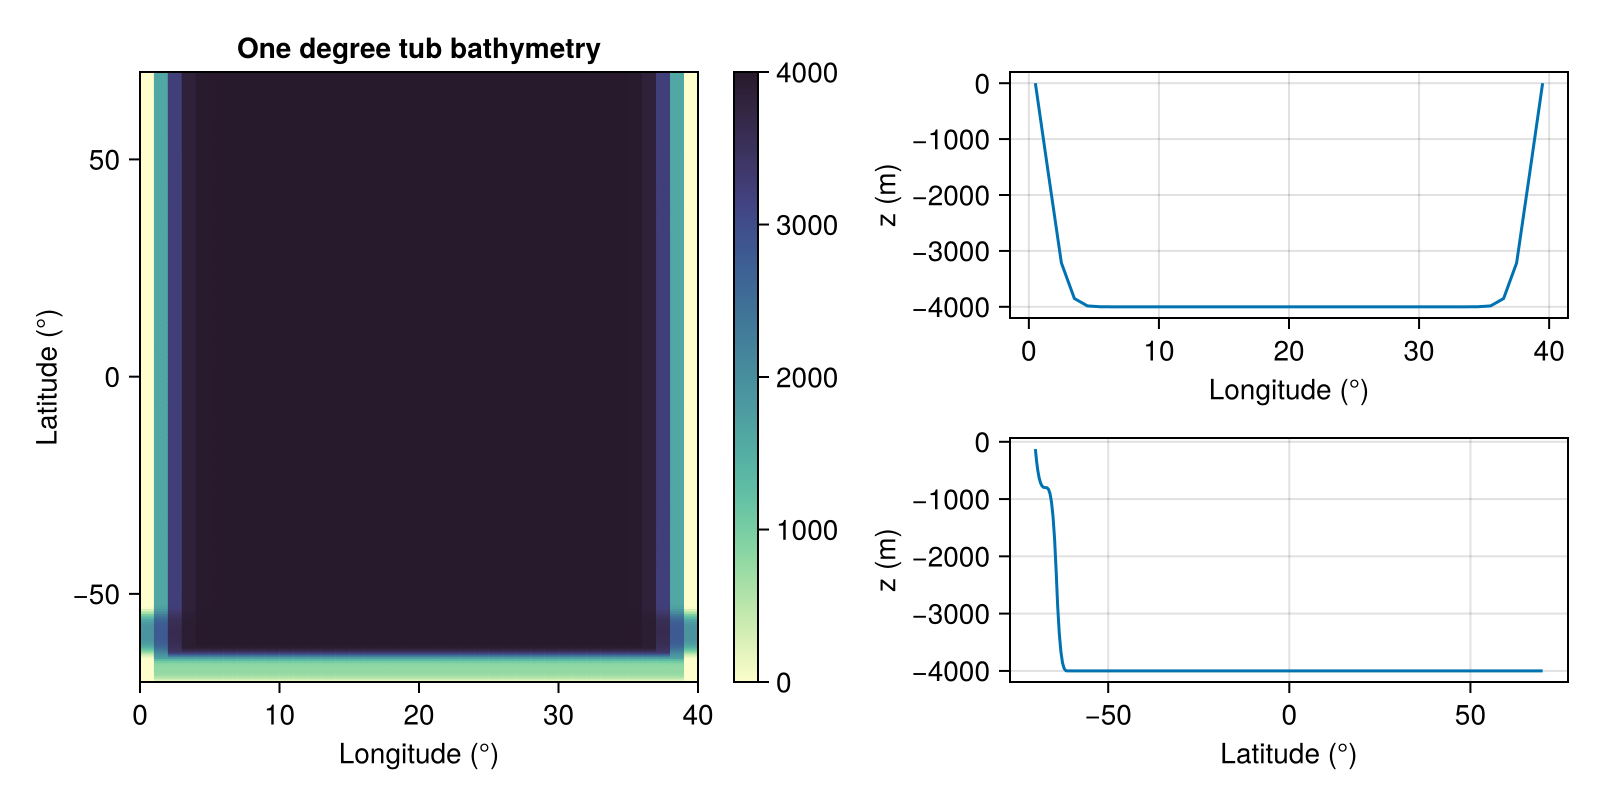

In [6]:
fig = Figure(size = (800, 400)) 
ax2 = Axis(fig[1, 3], xlabel = "Longitude (°)", ylabel = "z (m)")
lines!(ax2, x, -h[:, 100])
ax3 = Axis(fig[2, 3], xlabel = "Latitude (°)", ylabel = "z (m)")
lines!(ax3, y, -h[20, :])

ax = Axis(fig[:, 1], xlabel = "Longitude (°)", ylabel = "Latitude (°)",
            title = "One degree tub bathymetry")
hm = heatmap!(ax, x, y, h, colormap = :deep)
Colorbar(fig[:, 2], hm)

fig

# Now construct wind stress forcing
For now, just make reference case.


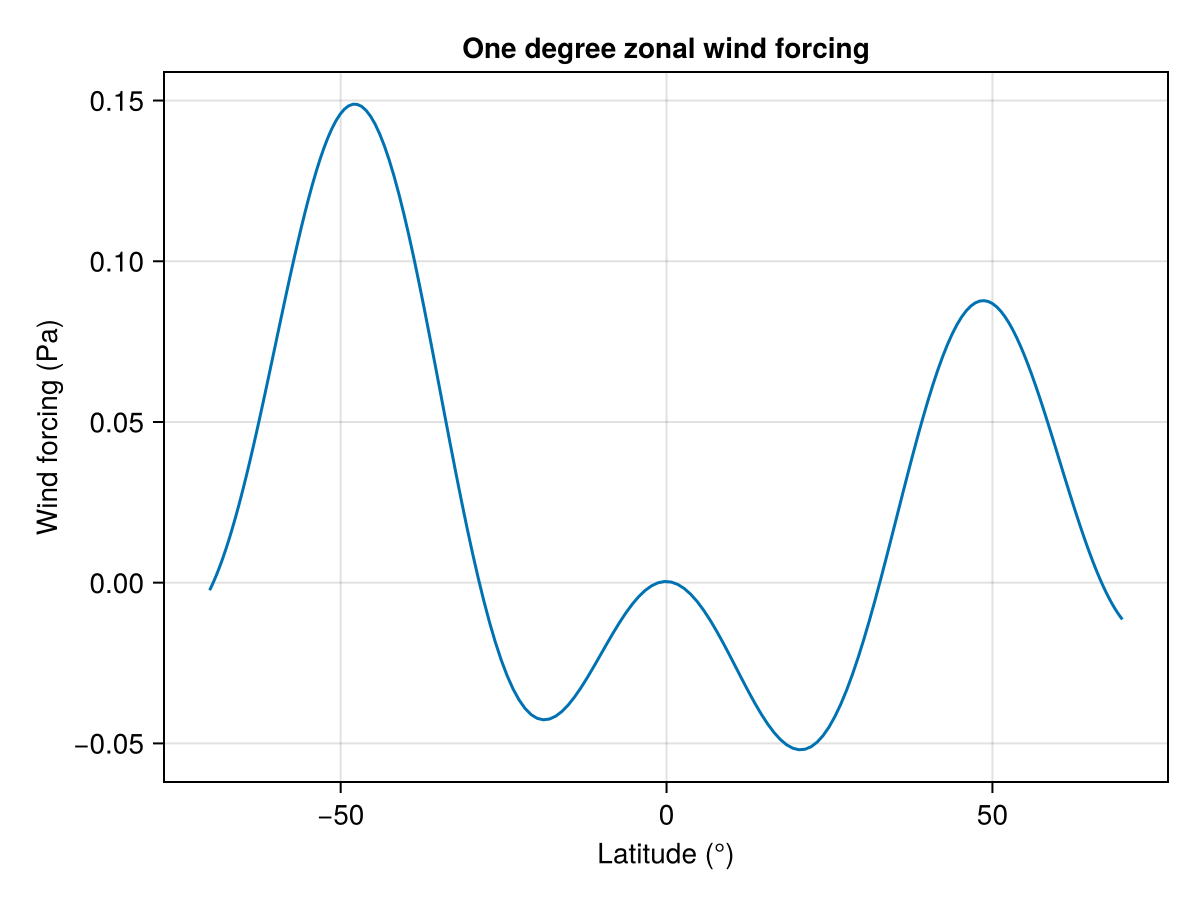

In [8]:
# Wind stress

tau_x = @. 0.03*(cos(4*2*pi*Y/180) - 1 + 5.1*exp(-((Y+50)/20)^2) + 3.2*exp(-((Y-53)/20)^2))

fig, ax = lines(y, tau_x[20, :])
ax.xlabel = "Latitude (°)"
ax.ylabel = "Wind forcing (Pa)"
ax.title = "One degree zonal wind forcing"
fig

# Construct SST relaxation file
The SST relaxation is an analytical form based on NOCS climatology, and used in previous thce experiments. We only make one SST file; buoyancy flux can be varied by changing either the diffusivity or restoring timescale, or can be simply switched off.

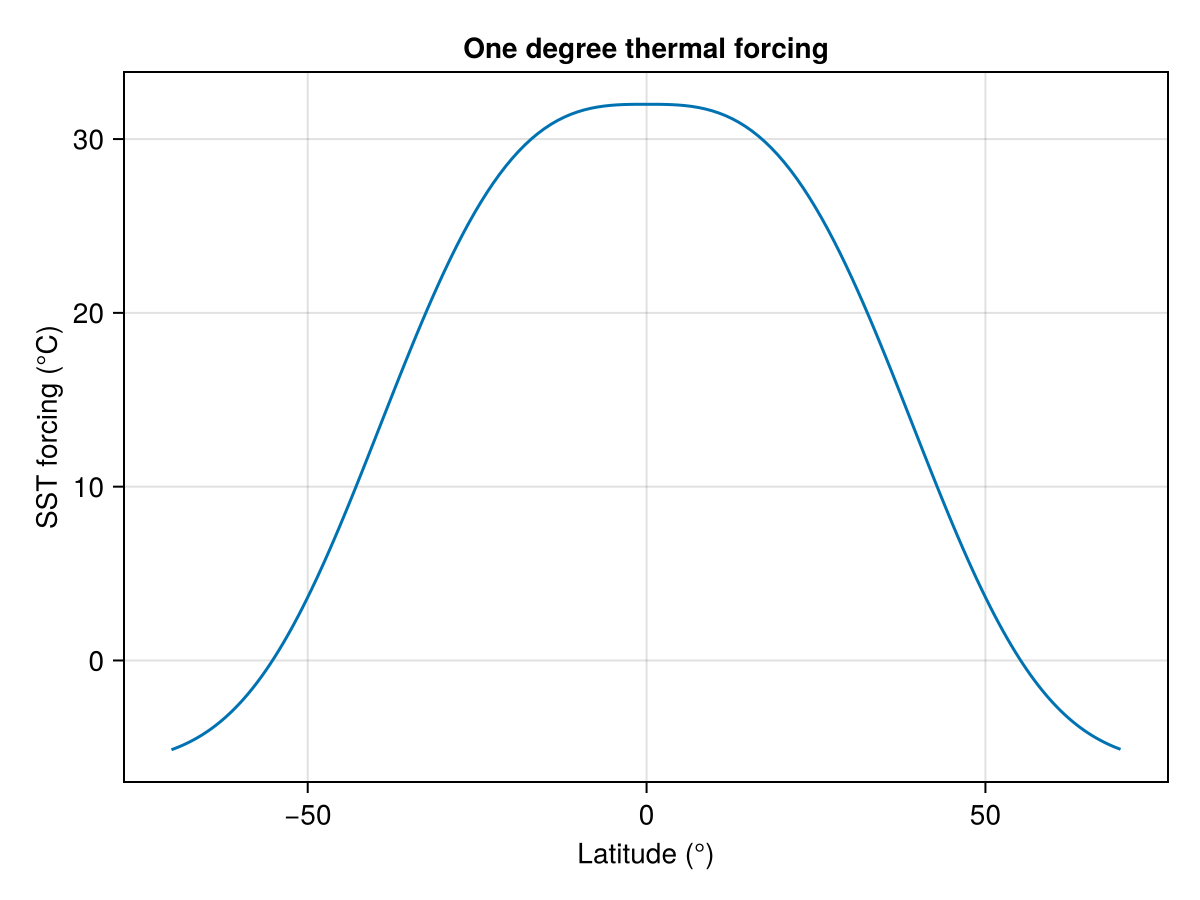

In [9]:
sst = @. 38*exp((-abs(Y)/45)^3) - 6

fig, ax = lines(y, sst[20, :])
ax.xlabel = "Latitude (°)"
ax.ylabel = "SST forcing (°C)"
ax.title = "One degree thermal forcing"
fig

# Generate the netcdf files needed for ANU-TUB

**NOTE:** each cell in the notebook needs to be run before this one so the appropriate variables can be found.

## Topography

In [10]:
NCDataset("one_degree_topog.nc", "c") do ds
    defDim(ds, "x", length(x))
    defDim(ds, "y", length(y))
    defVar(ds, "x", x, ("x",), 
          attrib = Dict("units" => "degrees east", 
                        "long_name" => "One degree resolution longitude for ANU-TUB",
                        "cartesian_axis" => "X"))
    defVar(ds, "y", y, ("y",), 
          attrib = Dict("units" => "degrees north", 
                        "long_name" => "One degree resolution latitude for ANU-TUB",
                        "cartesian_axis" => "Y"))
    defVar(ds, "topog", Float64.(h), ("x", "y"), 
          attrib = Dict("units" => "metres", "long_name" => "One degree resolution topogrpahy for ANU-TUB"))
end

Variable (dataset closed)

In [105]:
# ds = NCDataset("one_degree_topog.nc")
# fig, ax, hm = heatmap(ds["x"][:], ds["y"][:], ds["topog"][:, :])
# close(ds)
# fig

## Forcing

In [11]:
NCDataset("one_degree_forcing.nc", "c") do ds
    defDim(ds, "time", 1)
    defDim(ds, "x", length(x))
    defDim(ds, "y", length(y))
    defVar(ds, "time", Float64(0), ("time",))
    defVar(ds, "x", x, ("x",), 
          attrib = Dict("units" => "degrees east", 
                        "long_name" => "One degree resolution longitude for ANU-TUB",
                        "cartesian_axis" => "X"))
    defVar(ds, "y", y, ("y",), 
          attrib = Dict("units" => "degrees north", 
                        "long_name" => "One degree resolution latitude for ANU-TUB",
                        "cartesian_axis" => "Y"))
    defVar(ds, "tau_x", reshape(tau_x, (nx, ny, 1)), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "tau_y", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "SSS", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "LW", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "SW", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "froz_precip", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "froz_runoff", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "latent", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "liq_precip", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "liq_runoff", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "sensible", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
    defVar(ds, "evap", zeros(nx, ny, 1), ("x", "y", "time"), 
          attrib = Dict("units" => "Pascals", "long_name" => "One degree resolution forcing for ANU-TUB"))
end

Variable (dataset closed)

In [122]:
# ds = NCDataset("one_degree_forcing.nc")
# fig, ax = lines(ds["y"][:], ds["tau_x"][20, :, 1])
# close(ds)
# fig

## SST

In [12]:
NCDataset("one_degree_sst.nc", "c") do ds
    defDim(ds, "time", 1)
    defDim(ds, "x", length(x))
    defDim(ds, "y", length(y))
    defVar(ds, "time", Float64(0), ("time",), attrib = Dict("long_name" => "time"))
    defVar(ds, "x", x, ("x",), 
          attrib = Dict("units" => "degrees east", 
                        "long_name" => "One degree resolution longitude for ANU-TUB",
                        "cartesian_axis" => "X"))
    defVar(ds, "y", y, ("y",), 
          attrib = Dict("units" => "degrees north", 
                        "long_name" => "One degree resolution latitude for ANU-TUB",
                        "cartesian_axis" => "Y"))
    defVar(ds, "sst", reshape(sst, (nx, ny, 1)), ("x", "y", "time"), 
          attrib = Dict("units" => "degrees Celsius", "long_name" => "One degree resolution sst forcing for ANU-TUB"))
end

Variable (dataset closed)

In [126]:
# ds = NCDataset("one_degree_sst.nc")
# fig, ax = lines(ds["y"][:], ds["sst"][20, :, 1])
# close(ds)
# fig